# In this notebook, `trackio` is use to process and analyze AIS data from [Marine Cadastre](https://hub.marinecadastre.gov/pages/vesseltraffic).

## A subset of data at New York Harbor was downloaded for 1-month in 2025, though this workflow can be extended to smaller or larger datasets.

In this notebook we will:

* Read raw data
* Group data by unique vessel identifiers
* Split tracks based on several different conditions
* Map vessel type metadata to the raw data
* Reproject the data CRS
* Convert to GIS friendly formats
* Plot the data
* Rasterize vessel track counts into a heatmap
* Identify and simplify stops
* Generate several representations to visualize the most common routes
* Extract and plot cross-sectional distributions at key locations

In [1]:
import geopandas as gp
import trackio as tio
import matplotlib.pyplot as plt
import numpy as np
from shapely.geometry import MultiPolygon, LineString
from shapely.strtree import STRtree
from tqdm.dask import TqdmCallback
import rasterio as rio
from rasterio.plot import show
from sklearn.cluster import HDBSCAN
from scipy.signal import savgol_filter
import pandas as pd

%matplotlib inline

c:\Users\dere\AppData\Local\miniconda3\envs\siren\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## The data was downloaded in CSV files from the Marine Cadastre website and clipped to a region of interest. It was then combined into a single file and exported to parquet format simply for size to upload onto GitHub.

In [2]:
# read the raw data
raw_df = pd.read_parquet("data.parquet")

## First let's make a column mapper so the names are standardized. At minimum, trackio expects `Time`,`X`,`Y` columns.

In [3]:
# make a column mapper so trackio can handle the data
col_mapper = {c: tio.mappers.columns.get(c, c) for c in raw_df.columns}

In [4]:
# inspect the columns
col_mapper

{'mmsi': 'MMSI',
 'base_date_time': 'base_date_time',
 'longitude': 'X',
 'latitude': 'Y',
 'sog': 'Speed',
 'cog': 'Coursing',
 'heading': 'Heading',
 'vessel_name': 'Name',
 'imo': 'IMO',
 'vessel_type': 'vessel_type',
 'status': 'Status',
 'length': 'Length',
 'width': 'Width',
 'draft': 'Draft'}

In [5]:
# modify a couple
col_mapper["base_date_time"] = "Time"
col_mapper["vessel_type"] = "AISCode"

## Now create the trackio dataset object, from raw_df since the data is already loaded.

In [6]:
ds = tio.Dataset(data_path="./processed", raw_df=raw_df)


No dataset.db found in c:\code\trackio\notebooks\example1_AIS\processed. 
Using default units/crs. 
Edit self.meta and then run self.refresh_meta to update.



## Now, group the points into individual vessels using the MMSI field. Here, you can maintain `meta_cols` as static variables for each vessel, and `data_cols` for dynamic variables on each track. At minimum, `data_cols` must have `Time,X,Y`.

In [7]:
# group by the points by MMSI
ds = ds.group_points(
    meta_cols=["Draft", "IMO", "Length", "Width", "MMSI", "Name", "AISCode"],
    data_cols=["Time", "X", "Y", "Speed", "Coursing", "Heading", "Status"],
    groupby="MMSI",
    col_mapper=col_mapper,
    ncores=4,
)

Grouping points: 100%|██████████| 4/4 [00:02<00:00,  1.45it/s]


## Now we can split the points into individual tracks. The most common method is using a spatiotemporal split. We still start with this and make adjustments in later cells.

In [8]:
# split using spatiotemporal thresholds
ds = ds.split_tracks_spatiotemporal(distance=0.15, time=3600 * 12, ncores=4)

Splitting tracks using spatiotemporal threshold: 100%|██████████| 1988/1988 [00:22<00:00, 86.85it/s] 


## `trackio` also has a dictionary of AIS integer codes -> string vessel types that is from [Marine Cadastre](https://coast.noaa.gov/data/marinecadastre/ais/VesselTypeCodes2018.pdf). This makes it easier to group data together by vessel category.

In [9]:
# map AISCode meta field to Type meta field on each vessel
ds = ds.map_meta(
    ["AISCode"], ["Type"], {"AISCode": tio.mappers.ais["Type"]}, ncores=4
)

Mapping metadata to agent: 100%|██████████| 1988/1988 [00:10<00:00, 195.46it/s]


## Let's also reproject to a local UTM zone so coordinates are easier to work with.

In [10]:
# reproject to UTM-18N
ds = ds.reproject_crs(32618, ncores=4)

Reprojecting CRS: 100%|██████████| 1988/1988 [00:11<00:00, 178.39it/s]


In [11]:
# refresh the metadata
# this updates ds.agents and ds.tracks
ds = ds.refresh_meta(ncores=4)

Refreshing metadata: 100%|██████████| 1988/1988 [00:15<00:00, 129.15it/s]


New meta/databases saved to c:\code\trackio\notebooks\example1_AIS\processed


## Print some very brief summaries of the number of points in the dataset, and how many vessels by type, and how many tracks by type.

In [12]:
ds.agents.npoints.sum(), ds.agents.Type.value_counts()

(6046851,
 Type
 Recreational    978
 Cargo           276
 Tug/Tow         215
 Passenger       208
 Other           118
 Tanker           71
 Fishing          43
 SAR              22
 Military          4
 Name: count, dtype: int64)

In [13]:
ds.tracks.Type.value_counts()

Type
Recreational    2545
Passenger       1826
Tug/Tow          890
Other            798
Cargo            378
Fishing          198
Tanker           184
SAR              170
Military          14
Name: count, dtype: int64

## At any time, if you close the session and want to pick up where you left off, you can just reload the dataset.

In [14]:
# open the dataset
ds = tio.Dataset(data_path="./processed")
ds

Type:
    <class 'trackio.Dataset.Dataset'>
Status:
    0 Unprocessed CSV Files
    0 Processed CSV Files
    0 Unsplit Agent Files
    1988 Split Agent Files
Static Data Fields:
    ['AISCode', 'Agent ID', 'Draft', 'IMO', 'Length', 'MMSI', 'Name', 'Type', 'Width']
Dynamic Data Fields:
    ['Coursing', 'Heading', 'Speed', 'Status', 'Time', 'X', 'Y']
Metadata:
    X: metre
    Y: metre
    CRS: EPSG:32618
Data Path:
    c:\code\trackio\notebooks\example1_AIS\processed

## Now let's read a polygonal domain file. This polygon was downloaded from free online resources. Since there are holes/islands in the polygon, it was manually adjusted in QGIS to ensure each separate polygon in the file has no holes. This is because `ds.classify_in_polygon` used later only looks at the exterior of polygons.

In [15]:
# read domain file, reproject to dataset CRS
domain = gp.read_file("ais_domain.gpkg").to_crs(ds.meta["CRS"])

## Let's quickly convert the tracks to GeoDataFrame, and plot by vessel type with the domain to see what we're working with.

Converting tracks to GeoDataFrame: 100%|██████████| 1988/1988 [00:14<00:00, 137.51it/s]


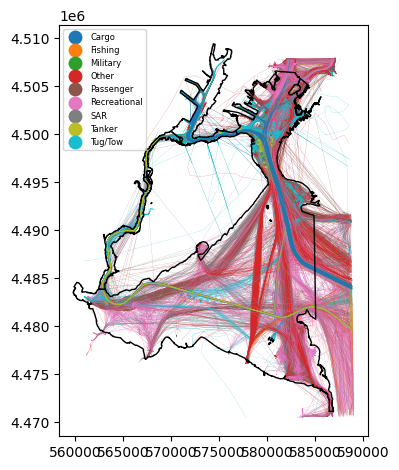

In [16]:
# convert dataset to geodataframe
gdf = ds.to_gdf(ncores=4)

# plot the tracks and domain
fig, ax = plt.subplots()
gdf.plot(
    ax=ax,
    zorder=0,
    linewidth=0.1,
    column="Type",
    legend=True,
    legend_kwds={"loc": "upper left", "fontsize": 6},
)
domain.plot(ax=ax, facecolor="none", zorder=1)
fig.tight_layout()

## We have over 6 million points, which can be hard to wield. One of the most obvious ways to reduce the data is to collapse extended stopping periods into their first and last points to eliminate points between that provide no value. Let's start by looking for stopping points.

In [17]:
# classify stops in the data using a speed threshold and min stop duration
ds = ds.classify_stops(
    stop_threshold=0.2,
    min_stop_duration=900,
    speed_col="Speed",
    code=1,
    ncores=4,
)

Classifying stopped tracks: 100%|██████████| 1988/1988 [00:05<00:00, 338.53it/s]


In [18]:
# convert only stops to dataframe, see how many we identified
stops = ds.to_df(code=1, ncores=4)
len(stops)

Converting tracks to DataFrame: 100%|██████████| 1988/1988 [00:16<00:00, 117.83it/s]


4033950

## It looks like there's a ton of points that can be reduced, this often happens when vessels leave their transponders on for extended periods of time.

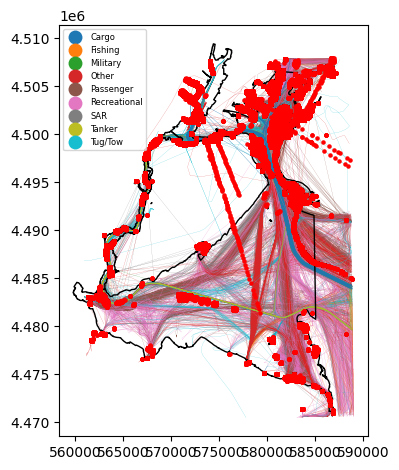

In [19]:
# plot the tracks, domain, and stopping points
fig, ax = plt.subplots()
gdf.plot(
    ax=ax,
    zorder=0,
    linewidth=0.1,
    column="Type",
    legend=True,
    legend_kwds={"loc": "upper left", "fontsize": 6},
)
domain.plot(ax=ax, facecolor="none", zorder=1)
ax.scatter(stops["X"], stops["Y"], c="r", s=5)
fig.tight_layout()

## Now let's simplify the stops by reducing them to the start and end points. One thing to be careful of here, is that anchorages might also be contributing to these stopping points. Anchorages can also be detected using `ds.compute_radius_of_curvature` and through custom algorithms, but this is not convered in this example.

In [20]:
# simplify stops to start/end points using the same stopping threshold
# also include a max_drift_distance to capture small deviation in location
ds = ds.simplify_stops(
    stop_threshold=0.2,
    min_stop_duration=900,
    max_drift_distance=100,
    speed_col="Speed",
    ncores=4,
)

Simplifying stops along tracks: 100%|██████████| 1988/1988 [00:30<00:00, 65.44it/s] 


In [21]:
# convert only stops to dataframe, see how many we reduced
stops = ds.to_df(code=1, ncores=4)
len(stops)

Converting tracks to DataFrame: 100%|██████████| 1988/1988 [00:11<00:00, 173.39it/s]


78303

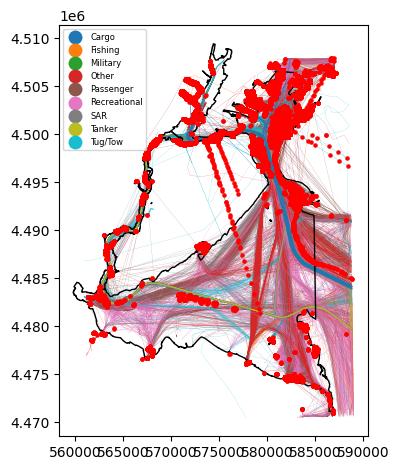

In [22]:
# plot the tracks, domain, and stopping points
fig, ax = plt.subplots()
gdf.plot(
    ax=ax,
    zorder=0,
    linewidth=0.1,
    column="Type",
    legend=True,
    legend_kwds={"loc": "upper left", "fontsize": 6},
)
domain.plot(ax=ax, facecolor="none", zorder=1)
ax.scatter(stops["X"], stops["Y"], c="r", s=5)
fig.tight_layout()

## It doesn't look that different :) but we reduced the number of points considerably.

## Now lets classify all the track points that are inside the domain, so we can chuck out anything outside. Note here I am combining all the domain polygons into a MultiPolygon because there are several in my domain file.

In [23]:
# classify points inside domain polygon
ds = ds.classify_in_polygon(
    MultiPolygon(domain.geometry.tolist()), code=2, ncores=4
)

Classifying tracks inside polygon: 100%|██████████| 1988/1988 [00:14<00:00, 141.56it/s]


## Here is an example to split the tracks even further into separate voyages. The simple spatiotemporal split might cause odd connections near the domain boundary if a vessel left and came back within the provided thresholds. As well, extended stops at a terminal/berth may be connected into one long track.

## First we split tracks where `Code2` changes, meaning inside and outside the domain. Then we split tracks where `Code1` changes, meaning splitting at stops. This is a good first approximation of individual voyages in the domain.

In [24]:
# split tracks inside/outside domain, and at stops
# note here I am passing track=ds.tracks.index as a kwarg
# this forces trackio to split the already existing tracks further
# instead of splitting the entire vessel's data, it's subsplitting
# the existing tracks
ds = ds.split_tracks_by_data(
    tracks=ds.tracks.index, data_col="Code2", ncores=4
)
ds = ds.split_tracks_by_data(
    tracks=ds.tracks.index, data_col="Code1", ncores=4
)
ds = ds.refresh_meta(ncores=4)

Refreshing metadata: 100%|██████████| 1988/1988 [00:35<00:00, 56.72it/s] 


New meta/databases saved to c:\code\trackio\notebooks\example1_AIS\processed


## Now remove all tracks that are outside the domain.

In [25]:
# the tracks outside the domain
track_ids = ds.tracks[~ds.tracks["Code2"]].index

# remove them and update meta tables
ds = ds.remove_tracks(track_ids, ncores=4)
ds = ds.refresh_meta(ncores=4)

Refreshing metadata: 100%|██████████| 1917/1917 [00:23<00:00, 81.43it/s] 


New meta/databases saved to c:\code\trackio\notebooks\example1_AIS\processed


In [26]:
# some simple cleanup, drop agents with very few points - subjective
agent_ids = ds.agents[ds.agents.npoints <= 10].index
ds = ds.remove_agents(agent_ids)
ds = ds.refresh_meta(ncores=4)

Refreshing metadata: 100%|██████████| 1763/1763 [00:21<00:00, 80.75it/s] 


New meta/databases saved to c:\code\trackio\notebooks\example1_AIS\processed


## Plot the updated and clipped tracks.

Converting tracks to GeoDataFrame: 100%|██████████| 1763/1763 [00:12<00:00, 139.28it/s]


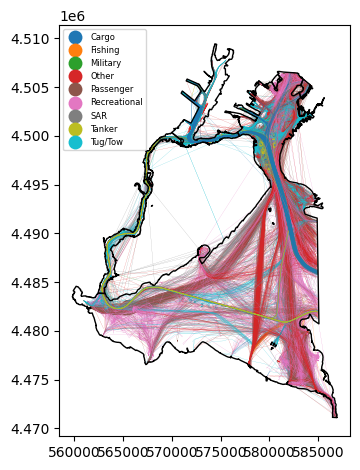

In [27]:
# convert updated dataset to geodataframe
gdf = ds.to_gdf(ncores=4)

# plot the tracks and domain
fig, ax = plt.subplots()
gdf.plot(
    ax=ax,
    zorder=0,
    linewidth=0.1,
    column="Type",
    legend=True,
    legend_kwds={"loc": "upper left", "fontsize": 6},
)
domain.plot(ax=ax, facecolor="none", zorder=1)
fig.tight_layout()

## As a first approximation of looking at main vessel routes, let's construct a flow map. For a quick analysis, a hexgrid was created in QGIS covering the domain.

In [28]:
# read the grid - add Code, X, Y columns for flow mapping
grid = gp.read_file("hexgrid.gpkg").to_crs(ds.meta["CRS"])
grid["Code"] = (np.arange(len(grid)) + 100).astype(int)
grid["X"] = grid.geometry.centroid.x
grid["Y"] = grid.geometry.centroid.y

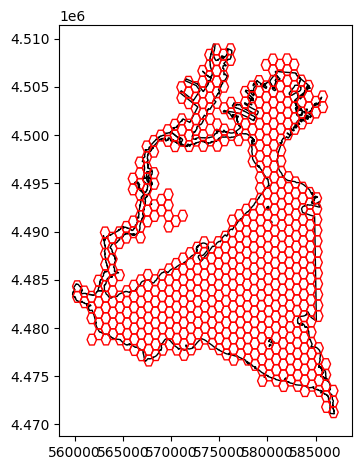

In [29]:
# plot the hexgrid and domain
fig, ax = plt.subplots()
domain.plot(ax=ax, facecolor="none")
grid.plot(ax=ax, facecolor="none", edgecolor="r")
fig.tight_layout()

## Now let's reduce tracks to their characteristic points before routing through the hexgrid. This effectively reduces tracks to their stop points, major turns, and reduces their spatial resolution as well. This is just an example, and may require tweaking, but provides the method to reduce track size while maintaining an acceptable level of detail.

In [30]:
# reduce tracks to characteristic points
# using same stop thresholds as before
# using a 22.5 degree turn indicator
# distance between points must be >=250m and <=10000m
# inplace=True removes non characteristic points
# out_path write the reduced data to a separate dataset
char = ds.characteristic_tracks(
    stop_threshold=0.2,
    min_stop_duration=900,
    turn_threshold=22.5,
    min_distance=250,
    max_distance=10000,
    ncores=4,
    inplace=True,
    out_path="./characteristic",
)

char = char.refresh_meta(ncores=4)

Refreshing metadata: 100%|██████████| 1763/1763 [00:22<00:00, 76.90it/s] 


New meta/databases saved to c:\code\trackio\notebooks\example1_AIS\characteristic


## Now we need to route the characterisic points through the hexgrid polygons. Trackio does have a `ds.classify_in_polygons` method for this kind of situation, but it can be slow when your number of polygons is in the hundreds or thousands.

## An alternative method is to generate an STRtree and parallize in dask as shown below.

In [31]:
# make RTree of the grid
tree = STRtree(grid.geometry.tolist())


# merge polygons back onto track files
def merge_polygons(agent):
    # get the agent file
    file = agent.agent_meta["File"]
    # loop over tracks
    for tid in agent.tracks.keys():
        # the track
        track = agent.tracks[tid]
        # convert track points to geoseries
        pts = gp.GeoSeries(gp.points_from_xy(track["X"], track["Y"]))
        # find the chain of hexgrid intersections
        polys = pts.apply(lambda p: tree.query(p, predicate="intersects")[0])
        # add hexgrid Codes as FlowPolygon column on track
        track["FlowPolygon"] = grid["Code"].values[polys.values]
        # reset the track on the agent
        agent.tracks[tid] = track
    # write it back out
    tio.write_agent(file, agent)
    return


# parallelize this function using dask bag
with TqdmCallback(desc="Classifying in polygons"):
    _ = char.to_dask_bag().map(merge_polygons).compute()

Classifying in polygons: 100%|██████████| 706/706 [00:13<00:00, 52.96it/s] 


## Now each track contains a `FlowPolygon` column, so we can easily generate a flow map.

In [32]:
# generate flow map using characteristic dataset
flow = char.generate_flow_map(
    grid, characteristic_col="Characteristic", flow_col="FlowPolygon", ncores=4
)

Generating flow map from polygons: 100%|██████████| 1763/1763 [00:13<00:00, 126.52it/s]


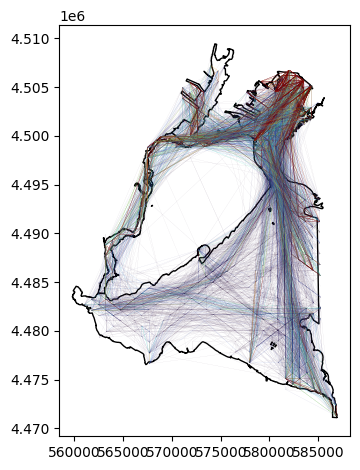

In [33]:
# plot the domain and flowmap colored/scaled by volume
# each edge in the flowmap is unidirectional, so where there is bidirectional
# traffic, there will be two overlapping edges with separate volumes
fig, ax = plt.subplots()
domain.plot(ax=ax, facecolor="none", zorder=1)
flow.plot(
    ax=ax,
    column="Volume",
    linewidth=(flow["Volume"] ** 0.5) / 50,
    cmap="turbo",
    vmax=20,
)
fig.tight_layout()

## In some domains, this is a very useful first step, however in this domain there is alot of complicated traffic and different scales of geometric constraints, so it's not so useful.

## Now write the original full data to a GeoPackage file for simple rasterization of track density.

In [34]:
# write full dataset to geopackage - you can drag and drop this into GIS at this point
gdf.to_file("tracks.gpkg", overwrite=True)

In [35]:
# create a blank 100mx100m raster covering the data extent
xmin, ymin, xmax, ymax = gdf.total_bounds
dx = dy = 100
tio.create_blank_raster(
    out_file="blank.tif",
    crs=ds.meta["CRS"],
    grid={
        "x0": xmin,
        "y0": ymin,
        "nx": int((xmax - xmin) // dx + 1),
        "ny": int((ymax - ymin) // dy + 1),
        "dx": dx,
        "dy": dy,
    },
)

Raster created and saved to blank.tif!


In [36]:
# rasterize the track counts into the blank raster
tio.rasterize("tracks.gpkg", "blank.tif", "track_counts.tif")

Track Counts written to c:\code\trackio\notebooks\example1_AIS\track_counts.tif


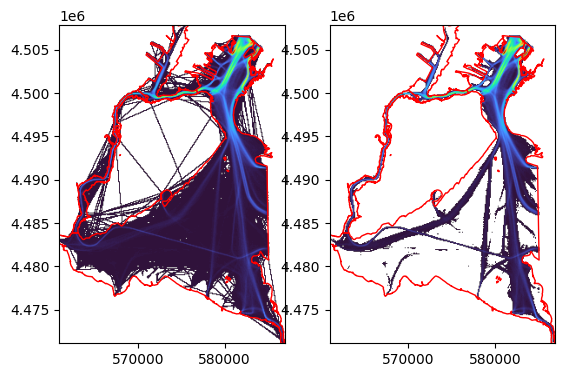

In [37]:
# create figure
fig, ax = plt.subplots(1, 2)

# plot full density unfiltered
domain.plot(ax=ax[0], facecolor="none", zorder=1, edgecolor="r")
with rio.open("track_counts.tif", "r") as f:
    dat = f.read(1)
    show(f, cmap="turbo", ax=ax[0])
    ax[0].invert_yaxis()

# plot density masking some low values to help reveal main routes
domain.plot(ax=ax[1], facecolor="none", zorder=1, edgecolor="r")
with rio.open("track_counts.tif", "r") as f:
    dat = f.read(1)
    masked_data = np.ma.masked_where(dat < 20, dat)
    show(masked_data, transform=f.transform, cmap="turbo", ax=ax[1])
    ax[1].invert_yaxis()

## Now we will try to cluster voyages together in an attempt to generate a better representation of the main routes.

### Caution that this is only an example workflow, and would need to be adjusted for higher fidelity results.

In [38]:
# first reduce the data to only voyages
voyages = gdf[
    (~gdf["Code1"])  # moving legs only, not stop fragments
    & (gdf["Track Length"] > 2000)  # at least 2 km travelled
    & (gdf["npoints"] >= 10)
].copy()  # enough fixes to describe a path

## I've also created a few checkpoint lines to help separate distinct types of movements across the domain. The idea here being that voyages passing through the same series of checkpoints are good candidates for grouping into routes.

In [39]:
checkpoints = gp.read_file("checkpoints.gpkg").to_crs(ds.meta["CRS"])

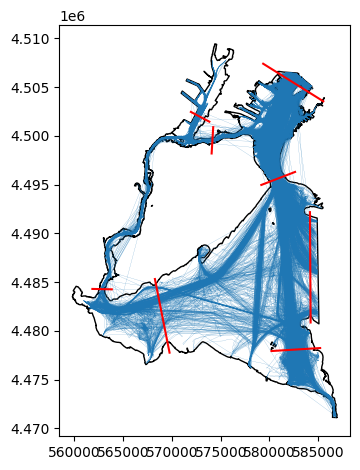

In [40]:
# plot the domain, voyages, and checkpoints
fig, ax = plt.subplots()
domain.plot(ax=ax, facecolor="none", zorder=0)
voyages.plot(ax=ax, linewidth=0.1, zorder=1)
checkpoints.plot(ax=ax, zorder=2, color="r")
fig.tight_layout()

## Now we need to find which tracks actually intersect the checkpoints. As the `classify_touching` method is set up below, it will return `True` on the two bounding points along a track where that specific segment touches a checkpoint. This will be useful later so we can extract the chain of checkpoints, instead of merely knowing if the track touched a checkpoint.

In [41]:
# loop over checkpoints
for i in range(len(checkpoints)):
    # single checkpoint LineString
    geom = checkpoints.geometry.iloc[i]
    # quick filter to see which voyages intersect it
    overlaps = voyages[voyages.intersects(geom)].index
    # add a boolean column to these tracks where the intersection occurs
    ds = ds.classify_touching(
        geom,
        tracks=overlaps,  # subset of overlapping tracks
        ncores=4,
        segments=True,  # find the specific segment where it occurs
        code=i + 1000,
    )

Classifying tracks touching object: 100%|██████████| 117/117 [00:03<00:00, 32.19it/s]


## Now we need to extract the chain of checkpoints passed by each voyage

## This function essentially filters tracks to the checkpoint Code columns, and finds the order in which it passed a checkpoint.

In [42]:
# the checkpoint code columns added to voyages
codes = [f"Code{i + 1000}" for i in range(len(checkpoints))]


# function to get the checkpoint chains
def get_checkpoints(agent):
    # agent id
    aid = agent.agent_meta["Agent ID"]
    # initialize empty out list
    out = []
    # loop over track ids
    for tid in agent.tracks.keys():
        # uniq identifier for track
        uid = aid + "_" + tid
        # the track
        track = agent.tracks[tid]
        # the checkpoint columns in the track dataframe
        filter_cols = [c for c in codes if c in track.columns]
        # if none (i.e. didn't pass a checkpoint) then append empty
        if len(filter_cols) == 0:
            out.append([uid, []])
        # if checkpoints
        else:
            # filter the track
            track = track[filter_cols]
            # initialize chain of checkpoints
            chain = []
            # loop over the track points
            for i in range(len(track)):
                # get the row
                row = track.iloc[[i]].values
                # find which checkpoint column is True
                if True in row:
                    idx = np.argmax(row)
                    col = track.columns[idx]
                    # append to chain
                    chain.append(col)
            # because classify_touching adds a True to the bounding points
            # of touching segments, each checkpoint is repeated
            # here reduce them to the unique chain of single checkpoints
            uniq = []
            for j, c in enumerate(chain):
                if j == 0:
                    uniq.append(c)
                else:
                    if uniq[-1] == c:
                        pass
                    else:
                        uniq.append(c)
            # append uid and unique checkpoint chain
            out.append([uid, uniq])
    # return list of uids and chains for this vessel
    return out


# parallelize this function using dask bags over all vessels
with TqdmCallback(desc="Getting checkpoint chains"):
    out = ds.to_dask_bag().map(get_checkpoints).compute()

Getting checkpoint chains: 100%|██████████| 706/706 [00:12<00:00, 56.99it/s] 


## Then, add the information back to the voyages geodataframe for later.

In [43]:
# merge the chains from the dask function
chains = {sub[0]: sub[1] for o in out for sub in o}

# add to voyages geodataframe
voyages["chains"] = [chains[tid] for tid in voyages.index]
voyages["route"] = ["-".join(c) if c else "<none>" for c in voyages["chains"]]

## To group voyages by their shape, each one is resampled to the same number of equally spaced points. This gives every voyage an identical length feature vector, so any two can be compared point-by-point regardless of how many raw fixes they contain.

In [44]:
# number of points to resample each voyage to
N = 20


# resample tracks to n equally spaced points -> (ntracks, n, 2)
def resample(gs, n=N):
    out = np.empty((len(gs), n, 2))
    # step along each track at n normalized distances
    for i, f in enumerate(np.linspace(0, 1, n)):
        p = gs.interpolate(f, normalized=True)
        out[:, i, 0] = p.x.values
        out[:, i, 1] = p.y.values
    return out


# resampled coordinates of every voyage
P = resample(voyages.geometry)
# centre the coordinates on the mean, per axis
C = P - P.reshape(-1, 2).mean(0)
# one pooled scale for X and Y so distances stay proportional to real ones
SD = C.reshape(-1, 2).std()
# flatten to a (ntracks, n*2) feature matrix for clustering
F = (C / SD).reshape(len(P), -1)

# helpers to convert between metres and feature space
eps = lambda m: np.sqrt(N) * m / SD
to_m = lambda d: d * SD / np.sqrt(N)

# the checkpoints below the mid-northing of the checkpoint set
# traffic down there is open water and diffuse, so it needs a looser tolerance
cpy = checkpoints.geometry.centroid.y
SOUTH_GATES = {
    f"Code{i + 1000}"
    for i in range(len(checkpoints))
    if cpy.iloc[i] < (cpy.min() + cpy.max()) / 2
}

## Now cluster the voyages. Rather than throwing everything at HDBSCAN at once, they are first grouped by their checkpoint chain, then clustered by shape within each group. This way the checkpoints handle the coarse routing, and the clustering only has to separate the different shapes taking the same chain.

## Chains with too few voyages are pooled into one group rather than being discarded, otherwise the quieter parts of the domain get dropped entirely.

In [45]:
# min voyages in a chain group to cluster it alone, and min voyages per cluster
MIN_GROUP, MCS = 30, 20
# clustering tolerance in metres, north and south
TOL_N, TOL_S = 300, 900

# track id -> row position in F
pos_of = {k: i for i, k in enumerate(voyages.index)}
# row positions of the voyages in each checkpoint chain
groups = {
    r: np.array([pos_of[i] for i in idx])
    for r, idx in voyages.groupby("route").groups.items()
}

# chains with enough voyages to cluster on their own
big = [(r, p) for r, p in groups.items() if len(p) >= MIN_GROUP]
# and everything else
rare = [p for p in groups.values() if len(p) < MIN_GROUP]
if rare:
    # pool the rare chains into one group, don't throw them away
    big.append(("<rare>", np.concatenate(rare)))

# -1 is noise, nxt keeps cluster ids unique across groups
labels, nxt = np.full(len(voyages), -1), 0
for r, pos in big:
    # looser tolerance if the chain uses a southern checkpoint
    tol = TOL_S if any(g in r for g in SOUTH_GATES) else TOL_N
    # cluster the voyage shapes within this chain
    sub = HDBSCAN(
        min_cluster_size=MCS, min_samples=5, cluster_selection_epsilon=eps(tol)
    ).fit_predict(F[pos])
    k = sub.max() + 1
    if k > 0:
        # offset the ids so they don't collide with other groups
        keep = sub >= 0
        labels[pos[keep]] = sub[keep] + nxt
        nxt += k

voyages["cluster"] = labels

## Because the resampled points run from the start of a track to its end, a route travelled one way lands nowhere near the same route travelled in reverse, so the two directions always cluster separately. Here each cluster is paired with its own reverse into a single corridor, keeping the direction in `cluster` and the shared path in `corridor`.

In [46]:
# the cluster ids and the mean shape of each one
ids = np.array(sorted(set(labels[labels >= 0])))
cent = np.stack([F[labels == c].mean(0) for c in ids])
# the same shapes with their point order reversed
rev = cent.reshape(len(ids), N, 2)[:, ::-1].reshape(len(ids), -1)
# distance in metres from each cluster to every reversed cluster
Dr = to_m(np.linalg.norm(cent[:, None] - rev[None, :], axis=-1))
np.fill_diagonal(Dr, np.inf)

# pair each cluster with its own reverse into one corridor
corridor, seen, nc = {}, set(), 0
for i, c in enumerate(ids):
    # already paired off
    if c in seen:
        continue
    corridor[c] = nc
    seen.add(c)
    # the closest reversed cluster
    j = Dr[i].argmin()
    # close enough means it's the same path travelled the other way
    if Dr[i, j] < 500 and ids[j] not in seen:
        corridor[ids[j]] = nc
        seen.add(ids[j])
    nc += 1

voyages["corridor"] = [corridor.get(c, -1) for c in labels]

# cluster sizes, and a north/south split to check coverage either side
vc = voyages.loc[voyages["cluster"] >= 0, "cluster"].value_counts()
cy = P[:, :, 1].mean(1)
south = cy < (cy.min() + cy.max()) / 2

print(
    f"{len(vc)} clusters in {nc} corridors | noise {100 * (labels == -1).mean():.1f}% "
    f"| biggest {100 * vc.iloc[0] / len(voyages):.1f}%"
)
print(
    f"  coverage   north {100 * (labels[~south] >= 0).mean():.1f}%"
    f"   south {100 * (labels[south] >= 0).mean():.1f}%"
)

103 clusters in 90 corridors | noise 17.5% | biggest 22.2%
  coverage   north 83.4%   south 72.3%


## Now plot the clustered routes. This is only an example workflow and would need to be adjusted to provide better results.

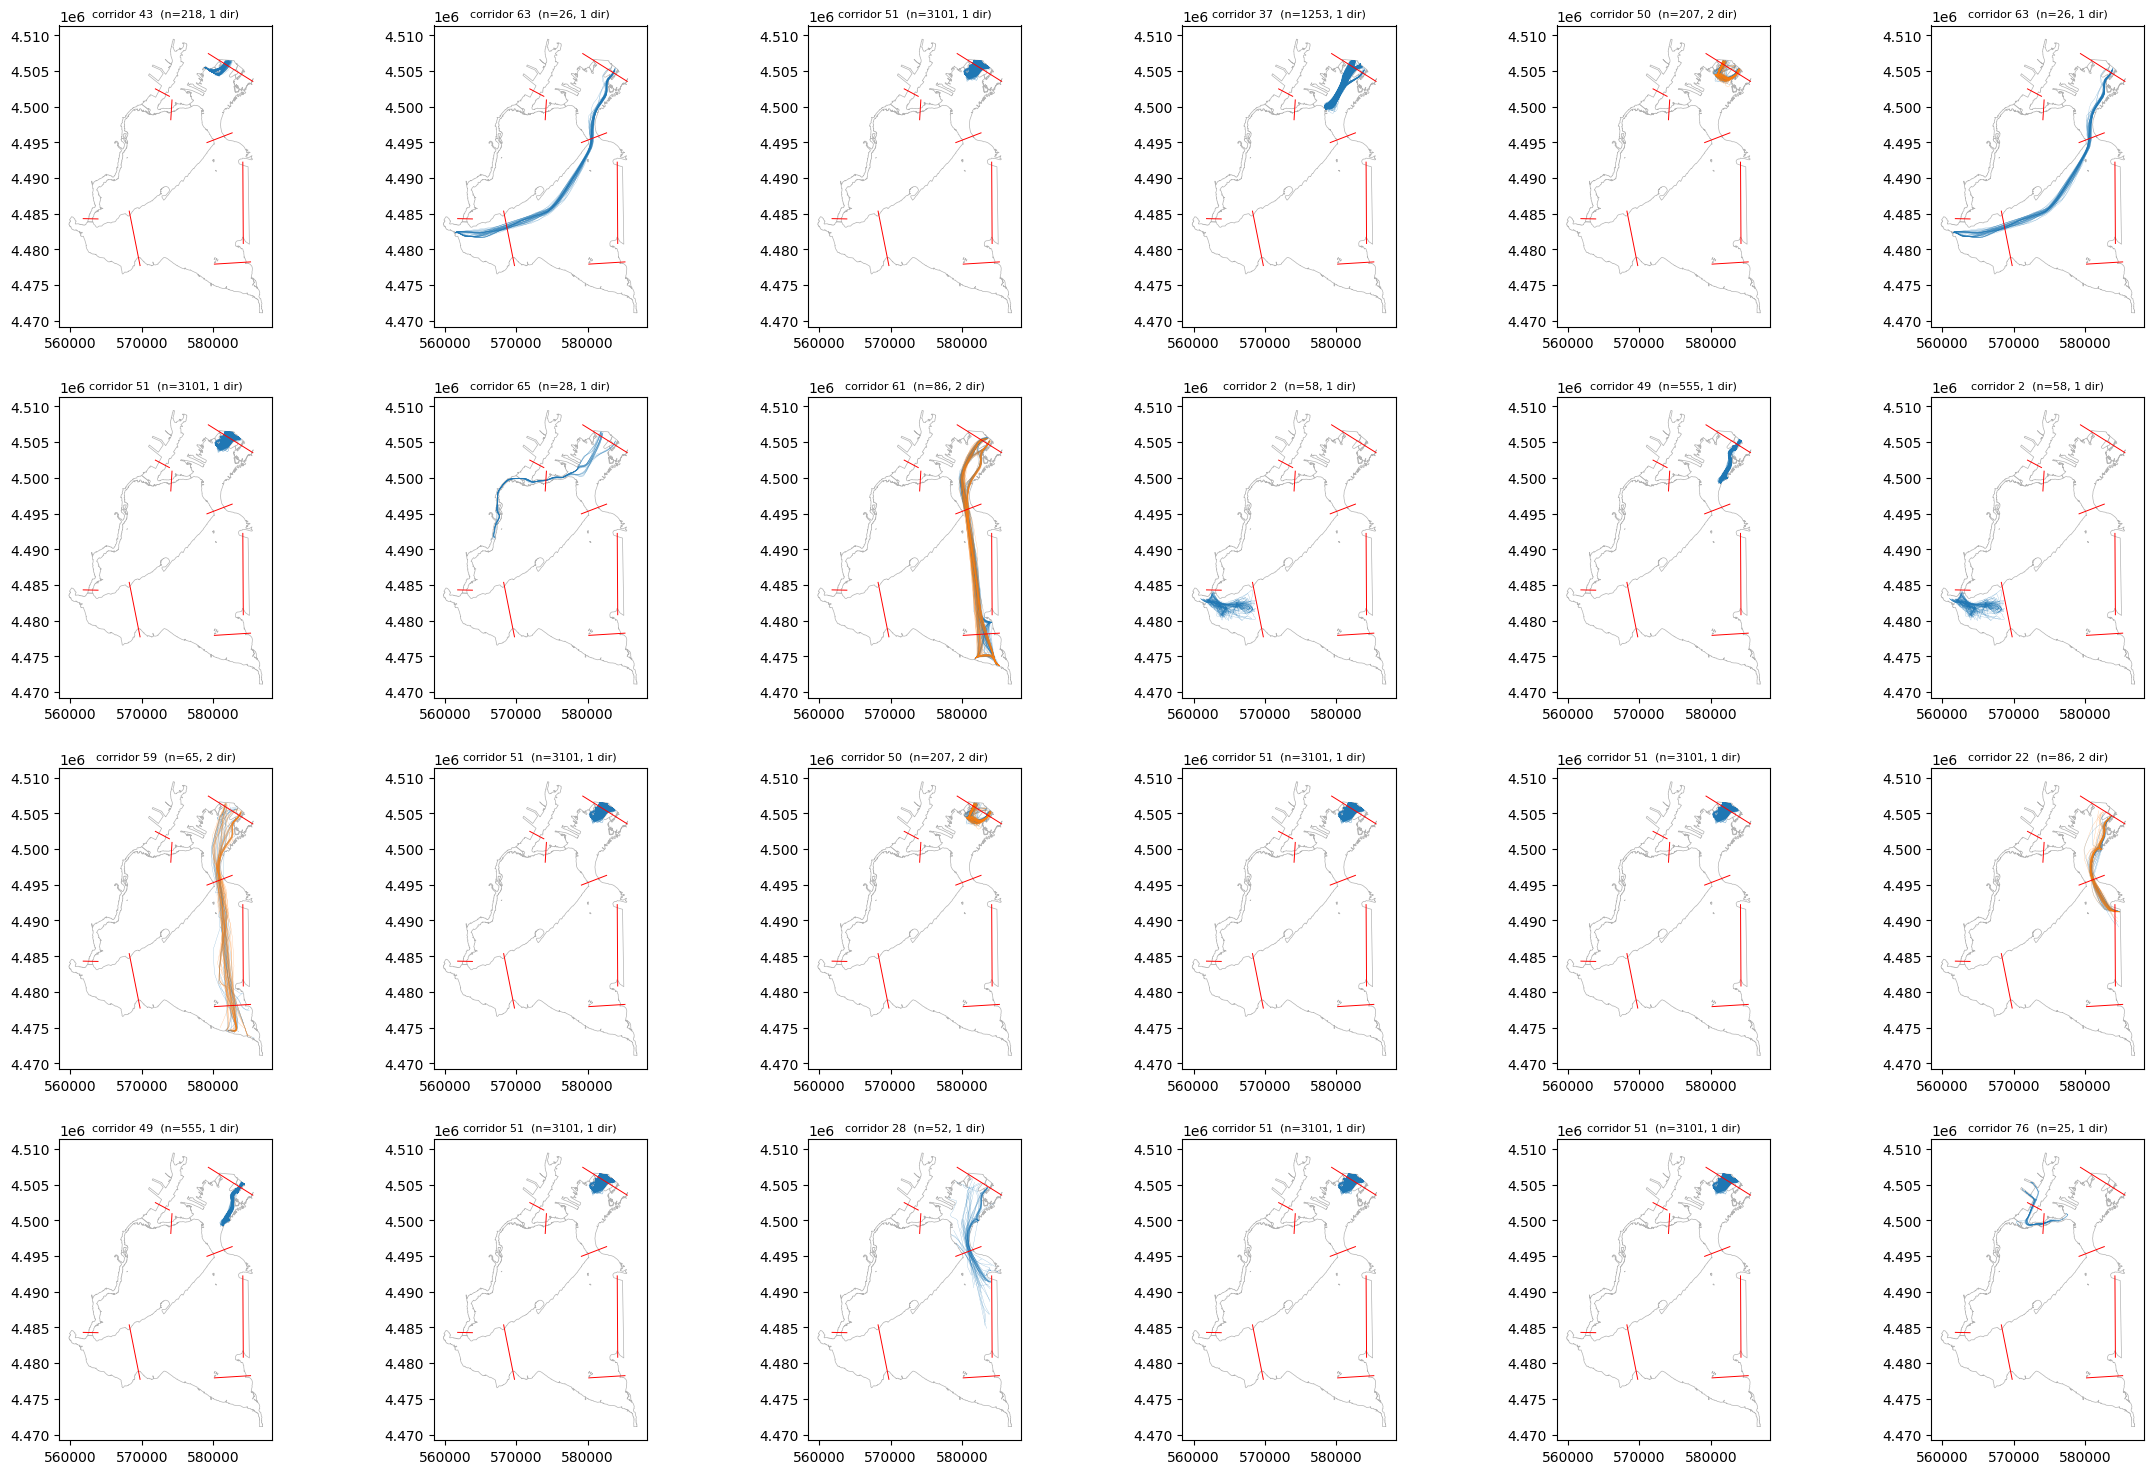

In [47]:
# a random sample of corridors to eyeball
corridors = (
    voyages.loc[voyages["corridor"] >= 0, "corridor"]
    .sample(24, replace=False)
    .values
)

# create plot figure
fig, axs = plt.subplots(4, 6, figsize=(23, 15))

# loop over the sampled corridors
for ax, kid in zip(axs.ravel(), corridors):
    domain.plot(ax=ax, facecolor="none", edgecolor="0.7", lw=0.5)
    # the voyages in this corridor
    sub = voyages[voyages["corridor"] == kid]

    # colour each direction separately
    for col, (cid, g) in zip(
        ["tab:blue", "tab:orange"], sub.groupby("cluster")
    ):
        g.plot(ax=ax, lw=0.2, color=col, alpha=0.55)
    # plot checkpoints
    checkpoints.plot(ax=ax, color="r", lw=0.7)
    # information about the corridor
    ax.set_title(
        f"corridor {kid}  (n={len(sub)}, {sub.cluster.nunique()} dir)",
        fontsize=8,
    )

fig.tight_layout()

## Finally, reduce each corridor to a single representative line. The voyages are resampled at higher resolution, flipped so they all run the same way, then collapsed to a point-by-point median. A median is used rather than a mean so a few stray voyages don't drag the line off the channel.

## The perpendicular spread of the voyages about that line is also kept as `halfwidth_p90_m`, which is a useful way to tell a tight shipping lane from a diffuse open water bundle.

In [48]:
# resample again at higher resolution, only for drawing the lines
M = 100
Q = resample(voyages.geometry, M)

rows = []
# loop over the corridors
for kid, idx in (
    voyages[voyages["corridor"] >= 0].groupby("corridor").groups.items()
):
    pos = np.array([pos_of[i] for i in idx])
    cl = labels[pos]

    # a corridor holds both directions, so flip them all to the biggest cluster's heading
    ref = np.median(
        Q[pos[cl == pd.Series(cl).value_counts().index[0]]], axis=0
    )
    pts = Q[pos].copy()
    flip = np.linalg.norm(pts[:, ::-1] - ref, axis=(1, 2)) < np.linalg.norm(
        pts - ref, axis=(1, 2)
    )
    pts[flip] = pts[flip][:, ::-1]

    # point by point median, then smooth out the jitter
    med = savgol_filter(np.median(pts, axis=0), 11, 3, axis=0)

    # unit tangent and normal along the medial line
    tan = np.gradient(med, axis=0)
    tan /= np.maximum(np.linalg.norm(tan, axis=1, keepdims=True), 1e-9)
    nrm = np.stack([-tan[:, 1], tan[:, 0]], axis=1)
    # how far off the line each voyage sits, perpendicular
    off = ((pts - med) * nrm).sum(-1)

    # the medial line for this corridor
    line = LineString(med)
    rows.append(
        {
            "corridor": kid,
            "ntracks": len(pos),
            "ndir": len(set(cl)),
            "length_km": line.length / 1000,
            "halfwidth_p90_m": float(
                np.percentile(np.abs(off), 90, axis=0).mean()
            ),
            "geometry": line,
        }
    )

medial = gp.GeoDataFrame(rows, crs=voyages.crs)

## And plot the resulting routes. There could be further refinement to snap together similar routes and produce a proper graph.

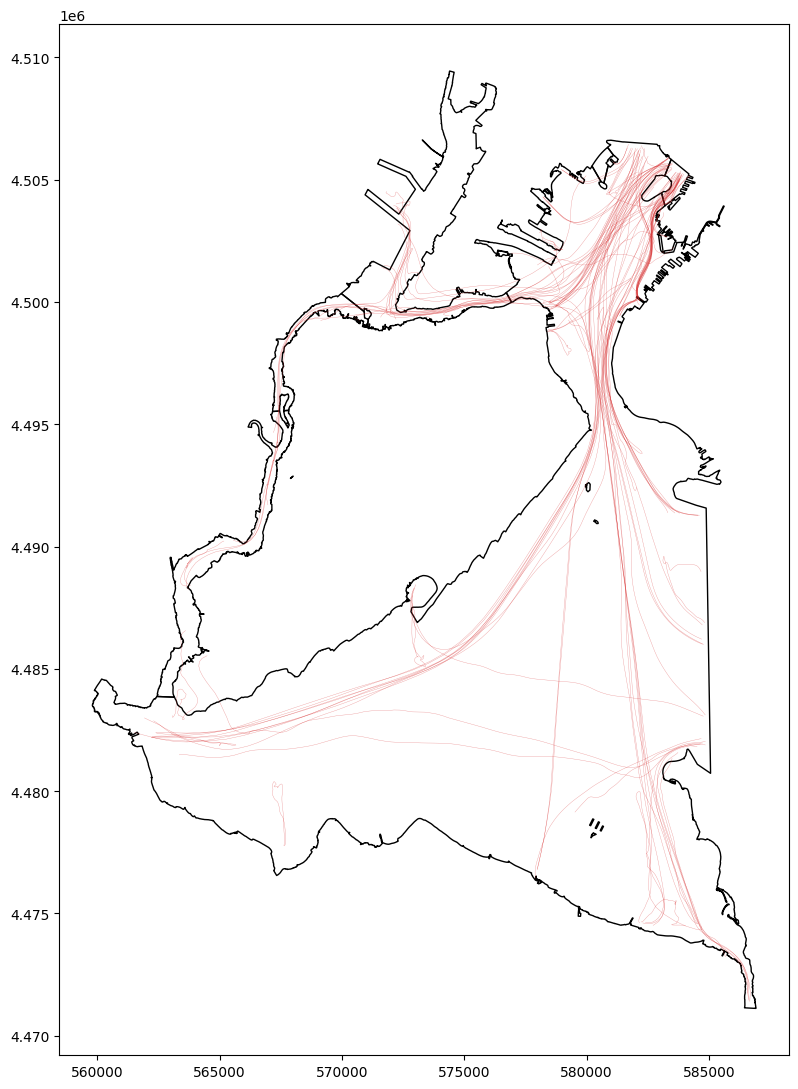

In [49]:
# plot the domain and the medial route of every corridor
fig, ax = plt.subplots(figsize=(9, 11))
domain.plot(ax=ax, facecolor="none")
medial.plot(ax=ax, color="tab:red", alpha=0.5, linewidth=0.25)
fig.tight_layout()

## Now let's take a cross section at the Verrazzano-Narrows Bridge, where most of the traffic is funnelling through.

In [50]:
# start and end centreline of cross-sections
# cross-sections are taken perpendicular to this centreline
start = (580904, 4495535)
end = (580598, 4496228)

# make cross-sectional distribution
xs = ds.lateral_distribution(
    start=start,
    end=end,
    n_slices=1,  # only 1 slice
    split=True,  # split by to/from direction through XS
    density=False,  # return raw counts not density
    bins=50,  # bin spatially 50m along XS
    ncores=4,
    data_cols=["Speed"],
)  # also return speeds at the XS

Calculating lateral distributions at slices: 100%|██████████| 1763/1763 [00:08<00:00, 209.18it/s]


## And plot the output.

Text(903.6045751633989, 0.5, 'Speed Reported (knots)')

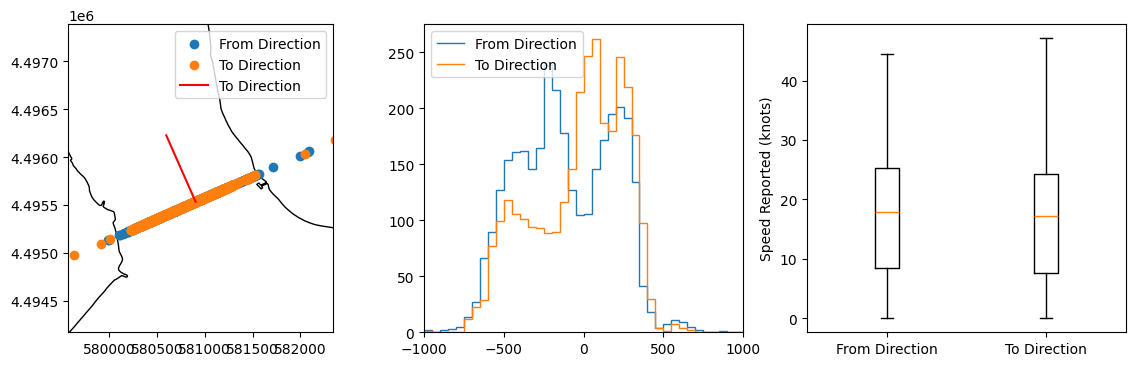

In [51]:
# make plot figure
fig, ax = plt.subplots(1, 3, figsize=(14, 4))

# plot the domain and XS points
domain.plot(ax=ax[0], facecolor="none")
ax[0].scatter(xs.iloc[0].TrackX, xs.iloc[0].TrackY, label="From Direction")
ax[0].scatter(xs.iloc[1].TrackX, xs.iloc[1].TrackY, label="To Direction")
ax[0].set_xlim(579572, 582344)
ax[0].set_ylim(4494170, 4497389)
ax[0].plot([start[0], end[0]], [start[1], end[1]], label="To Direction", c="r")
ax[0].legend()

# plot the XS volume in each direction
ax[1].stairs(xs.iloc[0].Frequency, xs.iloc[0].Bins, label="From Direction")
ax[1].stairs(xs.iloc[1].Frequency, xs.iloc[0].Bins, label="To Direction")
ax[1].set_xlim(-1000, 1000)
ax[1].legend()

# boxplot of speed distribution across the XS in each direction
s1 = np.array(xs.iloc[0]["Speed"])
s2 = np.array(xs.iloc[1]["Speed"])
ax[2].boxplot(
    [s1[~np.isnan(s1)], s2[~np.isnan(s2)]],
    tick_labels=["From Direction", "To Direction"],
)
ax[2].set_ylabel("Speed Reported (knots)")

## Note that the traffic is generally keeping to the starboard side, which is general COLREG compliant practice. While the speed seems reasonable, there are some outliers that could potentially be errors in the raw reported speed data (in knots). To explore this further, you could try computing the speeds based on time and point geometry using `ds.compute_speed`.